# Методы работы с несбалансированными данными

В этом ноутбуке реализуется лабораторная работа по сравнению классической модели машинного обучения на несбалансированных данных до и после применения методов балансировки обучающей выборки.

Используется табличный бинарный датасет Breast Cancer Wisconsin из `scikit-learn`. Чтобы получить выраженный дисбаланс классов, миноритарный класс дополнительно прореживается воспроизводимым способом.

## 1. Импорт библиотек и настройки

In [1]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from imblearn.combine import SMOTETomek
from imblearn.over_sampling import RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler
from sklearn.base import clone
from sklearn.datasets import load_breast_cancer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    ConfusionMatrixDisplay,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
plt.style.use("ggplot")

## 2. Загрузка и подготовка датасета

В исходном датасете целевая переменная кодируется как `0 = malignant`, `1 = benign`. Для удобства постановки задачи преобразуем ее так, чтобы положительный класс `1` соответствовал более редкому и важному классу `malignant`.

In [2]:
dataset = load_breast_cancer(as_frame=True)
df = dataset.frame.copy()

# 1 - malignant, 0 - benign
df["target"] = (df["target"] == 0).astype(int)

majority_df = df[df["target"] == 0]
minority_df = df[df["target"] == 1]

# Усиливаем дисбаланс: оставляем только часть объектов миноритарного класса.
minority_sample = minority_df.sample(n=70, random_state=RANDOM_STATE)
imbalanced_df = (
    pd.concat([majority_df, minority_sample], axis=0)
    .sample(frac=1, random_state=RANDOM_STATE)
    .reset_index(drop=True)
)

print("Размер исходного датасета:", df.shape)
print("Размер датасета после усиления дисбаланса:", imbalanced_df.shape)
imbalanced_df.head()

Размер исходного датасета: (569, 31)
Размер датасета после усиления дисбаланса: (427, 31)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,12.34,26.86,81.15,477.4,0.10340,0.13530,0.10850,0.045620,0.1943,0.06937,...,39.34,101.70,768.9,0.1785,0.47060,0.44250,0.14590,0.3215,0.12050,1
1,10.90,12.96,68.69,366.8,0.07515,0.03718,0.00309,0.006588,0.1442,0.05743,...,18.20,78.07,470.0,0.1171,0.08294,0.01854,0.03953,0.2738,0.07685,0
2,12.98,19.35,84.52,514.0,0.09579,0.11250,0.07107,0.029500,0.1761,0.06540,...,21.95,99.21,634.3,0.1288,0.32530,0.34390,0.09858,0.3596,0.09166,0
3,13.27,14.76,84.74,551.7,0.07355,0.05055,0.03261,0.026480,0.1386,0.05318,...,22.35,104.50,830.6,0.1006,0.12380,0.13500,0.10010,0.2027,0.06206,0
4,17.91,21.02,124.40,994.0,0.12300,0.25760,0.31890,0.119800,0.2113,0.07115,...,27.78,149.60,1304.0,0.1873,0.59170,0.90340,0.19640,0.3245,0.11980,1


## 3. Анализ дисбаланса классов

,class_name,count,share
target,,,
0,benign,357,0.836066
1,malignant,70,0.163934


Коэффициент дисбаланса: 5.10:1


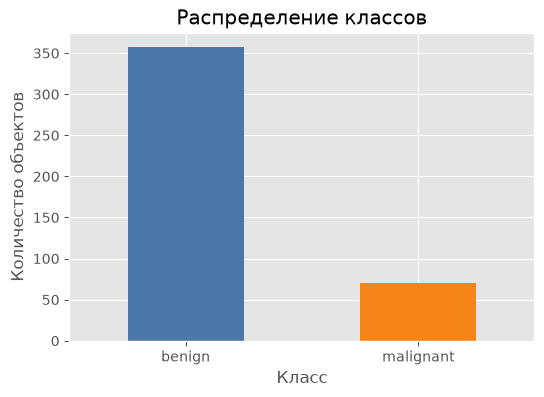

In [3]:
class_counts = imbalanced_df["target"].value_counts().sort_index()
class_names = {0: "benign", 1: "malignant"}
class_distribution = pd.DataFrame(
    {
        "class_name": class_counts.index.map(class_names),
        "count": class_counts.values,
        "share": class_counts.values / class_counts.sum(),
    },
    index=class_counts.index,
)

imbalance_ratio = class_counts.max() / class_counts.min()

display(class_distribution)
print(f"Коэффициент дисбаланса: {imbalance_ratio:.2f}:1")

ax = class_counts.rename(index=class_names).plot(kind="bar", figsize=(6, 4), color=["#4c78a8", "#f58518"])
ax.set_title("Распределение классов")
ax.set_xlabel("Класс")
ax.set_ylabel("Количество объектов")
plt.xticks(rotation=0)
plt.show()

Обычная `accuracy` при дисбалансе может быть завышенной: модель может часто выбирать мажоритарный класс и все равно получать высокий результат. Поэтому дополнительно используется `balanced accuracy`, которая усредняет качество по классам.

## 4. Разделение на обучающую и тестовую выборки

In [4]:
X = imbalanced_df.drop(columns="target")
y = imbalanced_df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=y,
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("Train distribution:")
display(y_train.value_counts().sort_index().rename(index=class_names))
print("Test distribution:")
display(y_test.value_counts().sort_index().rename(index=class_names))

Train shape: (320, 30)
Test shape: (107, 30)
Train distribution:


target
benign       268
malignant     52
Name: count, dtype: int64

Test distribution:


target
benign       89
malignant    18
Name: count, dtype: int64

## 5. Функции обучения и оценки

Балансировка применяется только к обучающей выборке. Тестовая выборка остается неизменной, чтобы оценка отражала качество на исходном распределении данных.

In [5]:
base_model = Pipeline(
    steps=[
        ("scaler", StandardScaler()),
        ("classifier", LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)),
    ]
)


def evaluate_strategy(strategy_name, sampler=None):
    if sampler is None:
        X_resampled, y_resampled = X_train, y_train
    else:
        X_resampled, y_resampled = sampler.fit_resample(X_train, y_train)

    model = clone(base_model)
    model.fit(X_resampled, y_resampled)

    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    train_distribution = y_resampled.value_counts().sort_index().to_dict()

    result = {
        "method": strategy_name,
        "train_class_0": train_distribution.get(0, 0),
        "train_class_1": train_distribution.get(1, 0),
        "accuracy": accuracy_score(y_test, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred),
        "recall": recall_score(y_test, y_pred),
        "f1": f1_score(y_test, y_pred),
        "roc_auc": roc_auc_score(y_test, y_proba),
    }

    return result, model, y_pred


strategies = {
    "Без балансировки": None,
    "Понижение выборки": RandomUnderSampler(random_state=RANDOM_STATE),
    "Повышение выборки": RandomOverSampler(random_state=RANDOM_STATE),
    "SMOTE + Tomek Links": SMOTETomek(random_state=RANDOM_STATE),
}

## 6. Обучение моделей

In [6]:
results = []
trained_models = {}
predictions = {}

for strategy_name, sampler in strategies.items():
    result, model, y_pred = evaluate_strategy(strategy_name, sampler)
    results.append(result)
    trained_models[strategy_name] = model
    predictions[strategy_name] = y_pred

results_df = pd.DataFrame(results).sort_values("balanced_accuracy", ascending=False).reset_index(drop=True)
display(results_df.style.format({
    "accuracy": "{:.3f}",
    "balanced_accuracy": "{:.3f}",
    "precision": "{:.3f}",
    "recall": "{:.3f}",
    "f1": "{:.3f}",
    "roc_auc": "{:.3f}",
}))

,method,train_class_0,train_class_1,accuracy,balanced_accuracy,precision,recall,f1,roc_auc
0,SMOTE + Tomek Links,266,266,0.963,0.933,0.889,0.889,0.889,0.990
1,Без балансировки,268,52,0.963,0.911,0.938,0.833,0.882,0.997
2,Понижение выборки,52,52,0.953,0.905,0.882,0.833,0.857,0.994
3,Повышение выборки,268,268,0.953,0.905,0.882,0.833,0.857,0.991


## 7. Визуальное сравнение метрик

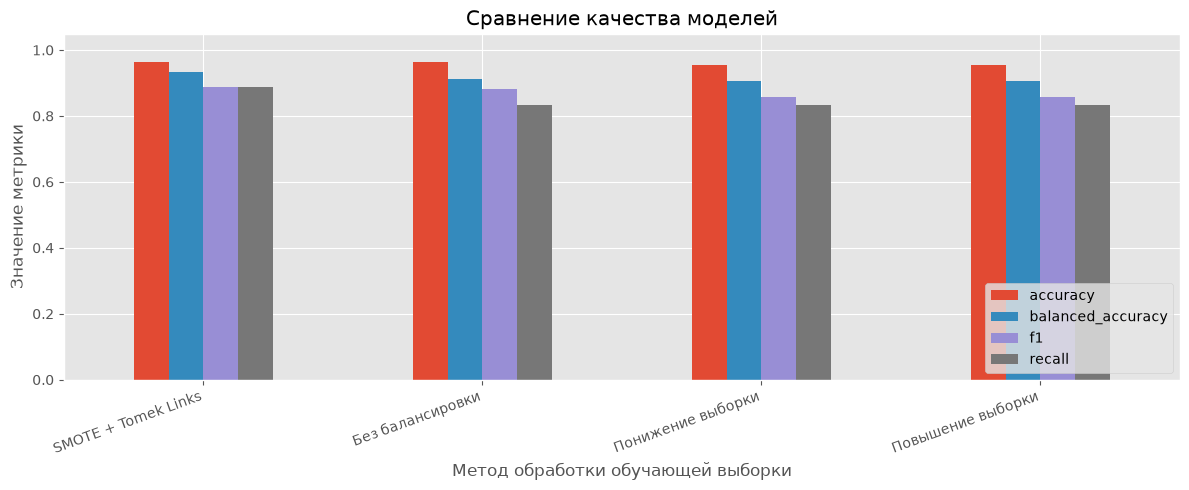

In [7]:
plot_df = results_df.set_index("method")[["accuracy", "balanced_accuracy", "f1", "recall"]]

ax = plot_df.plot(kind="bar", figsize=(12, 5))
ax.set_title("Сравнение качества моделей")
ax.set_xlabel("Метод обработки обучающей выборки")
ax.set_ylabel("Значение метрики")
ax.set_ylim(0, 1.05)
plt.xticks(rotation=20, ha="right")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

## 8. Матрица ошибок лучшей модели

Лучшая модель по balanced accuracy: SMOTE + Tomek Links
              precision    recall  f1-score   support

      benign       0.98      0.98      0.98        89
   malignant       0.89      0.89      0.89        18

    accuracy                           0.96       107
   macro avg       0.93      0.93      0.93       107
weighted avg       0.96      0.96      0.96       107



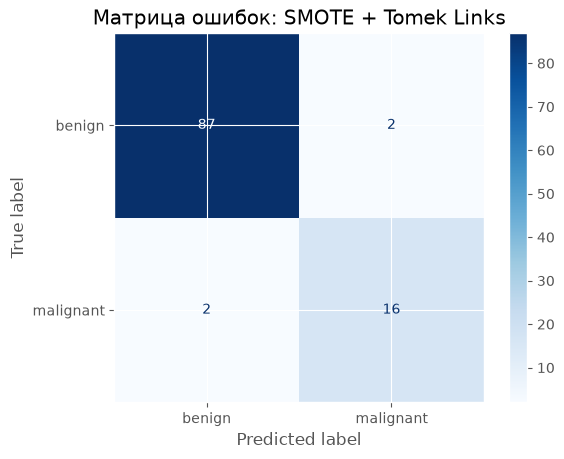

In [8]:
best_method = results_df.loc[0, "method"]
best_pred = predictions[best_method]

print(f"Лучшая модель по balanced accuracy: {best_method}")
print(classification_report(y_test, best_pred, target_names=["benign", "malignant"]))

cm = confusion_matrix(y_test, best_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["benign", "malignant"])
disp.plot(cmap="Blues", values_format="d")
plt.title(f"Матрица ошибок: {best_method}")
plt.show()

## 9. Выводы

In [9]:
baseline = results_df[results_df["method"] == "Без балансировки"].iloc[0]
best = results_df.iloc[0]

print("Итоговый вывод")
print("-" * 80)
print(f"Коэффициент дисбаланса в подготовленном датасете: {imbalance_ratio:.2f}:1.")
print(
    f"Базовая модель без балансировки: accuracy={baseline['accuracy']:.3f}, "
    f"balanced accuracy={baseline['balanced_accuracy']:.3f}."
)
print(
    f"Лучший метод: {best['method']} с accuracy={best['accuracy']:.3f}, "
    f"balanced accuracy={best['balanced_accuracy']:.3f}, recall={best['recall']:.3f}."
)
print(
    "Balanced accuracy и recall особенно важны в этой задаче, потому что миноритарный "
    "класс malignant является более критичным для обнаружения."
)

Итоговый вывод
--------------------------------------------------------------------------------
Коэффициент дисбаланса в подготовленном датасете: 5.10:1.
Базовая модель без балансировки: accuracy=0.963, balanced accuracy=0.911.
Лучший метод: SMOTE + Tomek Links с accuracy=0.963, balanced accuracy=0.933, recall=0.889.
Balanced accuracy и recall особенно важны в этой задаче, потому что миноритарный класс malignant является более критичным для обнаружения.
